In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [147]:
df = pd.read_csv(r'C:\Users\MINA\Documents\WeekilyPrac\Ml_JOUNRAL\ml-learning-journal\Time Series\Datasets\daily-minimum-temperatures-in-me.csv')

In [148]:
df.head()

,Date,Daily minimum temperatures
0,1/1/1981,20.7
1,1/2/1981,17.9
2,1/3/1981,18.8
3,1/4/1981,14.6
4,1/5/1981,15.8


In [149]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [150]:
df = df.rename(columns={'Daily minimum temperatures': 'Temp'})

In [151]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [152]:
df.dtypes

Temp    str
dtype: object

In [153]:
print(df['Temp'].unique())

<StringArray>
['20.7', '17.9', '18.8', '14.6', '15.8', '17.4', '21.8',   '20', '16.2',
 '13.3',
 ...
   '23', '24.1', '20.9', '23.4', '23.9', '19.8', '19.6',  '0.5',  '1.8',
 '21.6']
Length: 230, dtype: str


In [154]:
print(df['Temp'].unique()[:20])

<StringArray>
['20.7', '17.9', '18.8', '14.6', '15.8', '17.4', '21.8',   '20', '16.2',
 '13.3', '16.7', '21.5',   '25', '20.6', '24.8', '17.7', '15.5', '18.2',
 '12.1', '14.4']
Length: 20, dtype: str


In [155]:
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

In [156]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3647 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


In [157]:
print(df['Temp'].isna().sum())

3


In [158]:
df['Temp'] = df['Temp'].interpolate(method='linear')

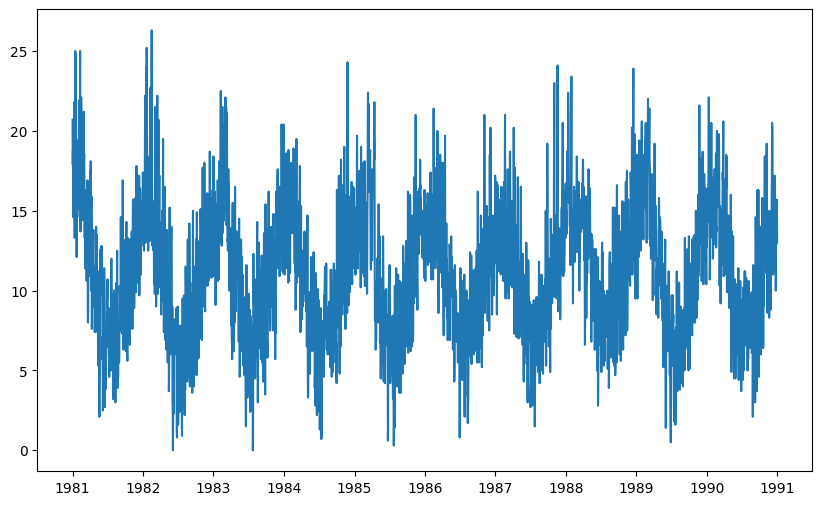

In [159]:
plt.figure(figsize=(10,6))
plt.plot(df['Temp'])
plt.show()

In [160]:
df['Rolling_Mean'] = df['Temp'].rolling(3).mean()
df['Rolling_Std'] = df['Temp'].rolling(3).std()


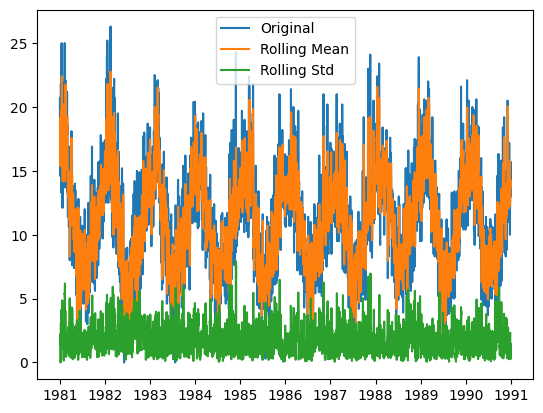

In [161]:
plt.plot(df['Temp'], label='Original')
plt.plot(df['Rolling_Mean'], label='Rolling Mean')
plt.plot(df['Rolling_Std'], label='Rolling Std')

plt.legend()
plt.show()

In [162]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(df['Temp'])
print(results[1])

0.00025147236020337904


In [163]:
if results[1]<0.05:
    print('Stationary')
else:
    print('Non-Stationary')

Stationary


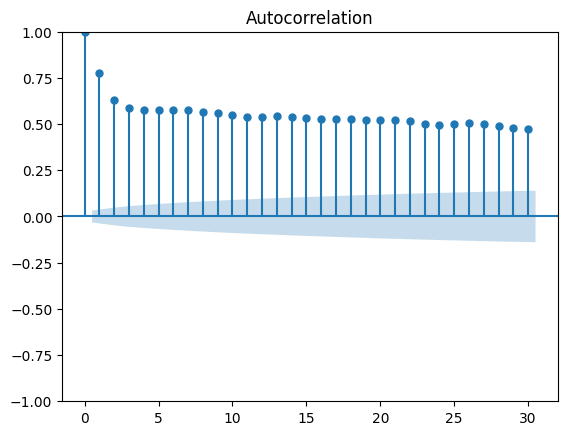

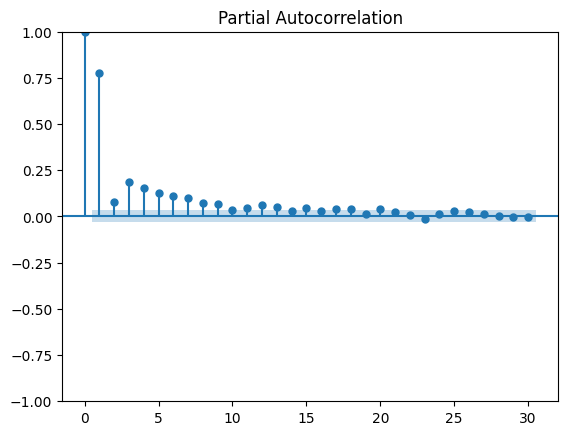

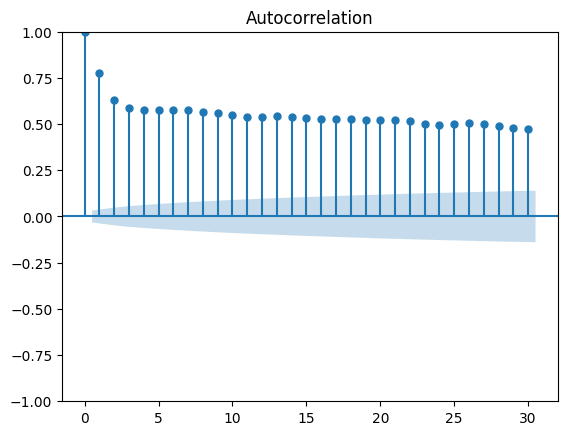

In [164]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plot_pacf(df['Temp'].dropna(),lags=30)
plot_acf(df['Temp'].dropna(), lags=30)

In [165]:
train = df.iloc[:-100]
test = df.iloc[-100:]

In [166]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Temp'], order=(1,1,1))
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [167]:
forecast = model_fit.forecast(steps=len(test))
forecast

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


3550    7.928387
3551    8.450934
3552    8.692923
3553    8.804986
3554    8.856881
          ...   
3645    8.901642
3646    8.901642
3647    8.901642
3648    8.901642
3649    8.901642
Name: predicted_mean, Length: 100, dtype: float64

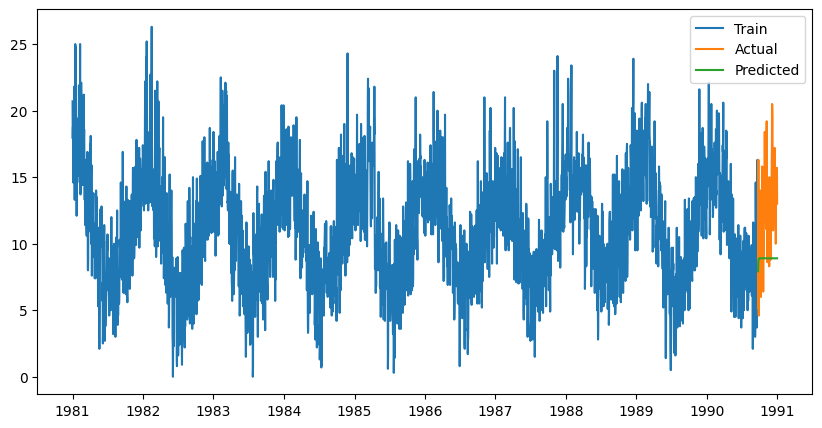

In [168]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train['Temp'], label='Train')
plt.plot(test.index, test['Temp'], label='Actual')
plt.plot(test.index, forecast, label='Predicted')

plt.legend()
plt.show()

In [169]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['Temp'], forecast)
rmse = np.sqrt(mean_squared_error(test['Temp'], forecast))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 3.9732936876874403
RMSE: 4.746197231642209
